# SR3 RV Lab — Framework 4: wing convexity harvest

**RV class: A — within-contract shape.**

Sell the OTM wing the market is paying up for, delta-hedge it daily, and keep
the premium if the tail does not arrive. Three constructions, in increasing
order of how much of the disaster you keep:

1. **naked wing + daily delta hedge** — the pure short-tail expression.
2. **wing vertical (disaster buyback)** — sell the near wing, buy the far one,
   so the loss is capped at the strike distance. This is the `convergence.py`
   "sell the meat / own the disaster" package in listed form.
3. **strangle** — both wings at once, delta-hedged, which removes the
   directional tilt and leaves the smile's wing level.

Signals are **premium-native**: the z-score of the listed wing premium itself
(and of the wing-vertical price), never a model tail probability. The prior
session's measurement stands — model-implied tail bases have sub-1-day
half-lives and their P&L is anti-correlated with executable P&L.

In [1]:
CONFIG = dict(
    near_offset=0.25,         # near wing, percent from the forward
    far_offset=0.50,          # far wing (the disaster buyback)
    strike_tol=0.13,
    min_oi=100,
    min_tte=0.15,
    contracts_per_leg=100,
    cost_bp=2.5,
    mas=(1, 5, 10),
    zscore_windows=(60, 120),
    entry_zs=(1.0, 1.5, 2.0),
    exits=("t5", "t10", "t20"),
    directions=("fade", "momentum"),
)
CONFIG

{'near_offset': 0.25,
 'far_offset': 0.5,
 'strike_tol': 0.13,
 'min_oi': 100,
 'min_tte': 0.15,
 'contracts_per_leg': 100,
 'cost_bp': 2.5,
 'mas': (1, 5, 10),
 'zscore_windows': (60, 120),
 'entry_zs': (1.0, 1.5, 2.0),
 'exits': ('t5', 't10', 't20'),
 'directions': ('fade', 'momentum')}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import LabConfig, load_lab, run_framework
from RVUtils.SFRRVLab import (
    Leg, Structure, add_event_distance, constant_maturity_slots, wing_panel,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]

parity completion: 199319 listed quotes + 191259 reconstructed (96.0%) so ITM legs stay marked


In [3]:
wings = wing_panel(quotes, contracts,
                   offsets=(CONFIG["near_offset"], CONFIG["far_offset"]),
                   tol=CONFIG["strike_tol"], min_oi=CONFIG["min_oi"])
tte = constant_maturity_slots(contracts)[["as_of", "symbol", "tte", "cm_slot"]]
wings = wings.merge(tte, on=["as_of", "symbol"], how="left")
wings = wings[wings["tte"] >= CONFIG["min_tte"]]
n, f = f"{CONFIG['near_offset']:g}", f"{CONFIG['far_offset']:g}"
need = [f"hk{n}_bp", f"ct{n}_bp", f"hk{f}_bp", f"ct{f}_bp",
        f"hk{n}_K", f"ct{n}_K", f"hk{f}_K", f"ct{f}_K"]
wings = wings.dropna(subset=need)
wings = add_event_distance(wings)
print(f"wing panel: {len(wings)} rows, {wings['symbol'].nunique()} symbols")
print(wings.groupby("symbol")[[f"hk{n}_bp", f"ct{n}_bp", f"hk{f}_bp", f"ct{f}_bp"]]
      .median().round(2).to_string())

wing panel: 3624 rows, 14 symbols
        hk0.25_bp  ct0.25_bp  hk0.5_bp  ct0.5_bp
symbol                                          
SFRH25      13.38      16.50      6.50     11.00
SFRH26      25.88      30.12     16.75     23.12
SFRH27      24.75      26.75     17.50     19.75
SFRH28      40.25      39.25     32.75     30.25
SFRM25      15.00      18.75      7.25     13.12
SFRM26      25.50      29.25     16.50     22.25
SFRM27      27.00      26.75     19.25     19.25
SFRM28      44.00      40.75     33.75     31.75
SFRU25      15.38      20.12      7.88     14.88
SFRU26      20.00      23.25     11.62     16.38
SFRU27      31.25      31.00     23.25     23.00
SFRZ25      20.62      25.50     11.38     19.12
SFRZ26      22.50      24.25     14.25     17.25
SFRZ27      34.88      34.00     27.50     25.50


## Signals

* `hike_wing` / `cut_wing`: the listed premium of the single wing.
* `wing_vertical`: the price of the near-minus-far wing spread — what the
  disaster buyback actually costs.
* `strangle`: both wings summed, the smile's wing level.

In [4]:
W = wings.rename(columns={"symbol": "key"}).copy()
W["hike_wing"] = W[f"hk{n}_bp"]
W["cut_wing"] = W[f"ct{n}_bp"]
W["wing_vertical"] = W[f"hk{n}_bp"] - W[f"hk{f}_bp"]
W["strangle"] = W[f"hk{n}_bp"] + W[f"ct{n}_bp"]
W["gate"] = True
print(W[["hike_wing", "cut_wing", "wing_vertical", "strangle"]]
      .describe().round(2).to_string())

KCOLS = W.set_index(["key", "as_of"])[
    [f"hk{n}_K", f"ct{n}_K", f"hk{f}_K", f"ct{f}_K"]].sort_index()


def _ks(key, date):
    try:
        r = KCOLS.loc[(key, date)]
    except KeyError:
        return None
    return r.iloc[0] if isinstance(r, pd.DataFrame) else r


def builder_naked(key, exec_date, direction):
    r = _ks(key, exec_date)
    if r is None:
        return None
    return Structure((Leg("option", key, 1.0, "P", float(r[f"hk{n}_K"])),),
                     label=f"hikewing {key}")


def builder_vertical(key, exec_date, direction):
    """Sell the near wing, own the far one — the disaster is bought back."""
    r = _ks(key, exec_date)
    if r is None:
        return None
    return Structure((Leg("option", key, 1.0, "P", float(r[f"hk{n}_K"])),
                      Leg("option", key, -1.0, "P", float(r[f"hk{f}_K"]))),
                     label=f"wingvert {key}")


def builder_strangle(key, exec_date, direction):
    r = _ks(key, exec_date)
    if r is None:
        return None
    return Structure((Leg("option", key, 1.0, "P", float(r[f"hk{n}_K"])),
                      Leg("option", key, 1.0, "C", float(r[f"ct{n}_K"]))),
                     label=f"strangle {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=0.25)
GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]


def _sig(col):
    s = W[["key", "as_of", "gate", "days_to_fomc", col]].copy()
    s["signal"] = s[col]
    return s.dropna(subset=["signal"])

       hike_wing  cut_wing  wing_vertical  strangle
count    3624.00   3624.00        3624.00   3624.00
mean       24.69     26.52           7.27     51.21
std        14.14     12.93           2.74     26.90
min         0.25      0.75           0.00      1.25
25%        13.00     16.75           6.25     29.50
50%        25.50     27.25           8.00     53.00
75%        36.25     36.75           9.00     73.06
max        54.25     55.00          15.50    105.75


## 4a — naked hike wing, delta-hedged daily

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 4a. Wing harvest (naked, hedged) — grid ===
  108 configs | median -345.03bp | IQR [-564.64, -246.71] | 0% net-positive | best -92.31bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   5            120               2.0        t20        52     0.442      -1.775       -92.308     -230770.25  -1.616    -95.672
 momentum   1             60               2.0        t20        67     0.313      -1.411       -94.559     -236398.25  -0.822    -99.263
 momentum   1            120               2.0        t20        56     0.446      -1.883      -105.428     -263571.00  -1.436   -111.600
 momentum  10            120               2.0        t20        52     0.442      -2.034      -105.771     -264427.50  -1.825   -113.308
 momentum  10             60               2.0        t20        52     0.385      -2.069      -107

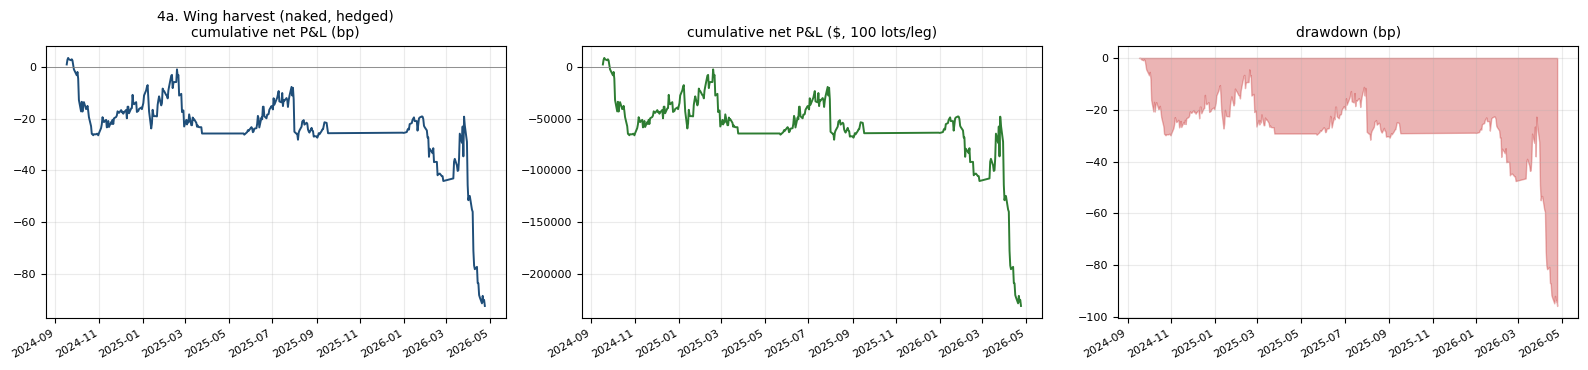


TRADE LOG (first rows)
   key  dir       structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRZ25   -1 hikewing SFRZ25  2024-09-13 2024-09-16 2024-10-14    20 -2.028   -1.0273      2.5 -3.5273  -8818.25         0.0            1.0        time
SFRU25   -1 hikewing SFRU25  2024-09-19 2024-09-20 2024-10-18    20 -2.524   -4.6003      2.5 -7.1003 -17750.68         0.0            1.0        time
SFRH26   -1 hikewing SFRH26  2024-09-20 2024-09-23 2024-10-21    20 -2.128   -4.7233      2.5 -7.2233 -18058.31         0.0            1.0        time
SFRM25   -1 hikewing SFRM25  2024-09-23 2024-09-24 2024-10-22    20 -2.340   -5.6382      2.5 -8.1382 -20345.57         0.0            1.0        time
SFRH25   -1 hikewing SFRH25  2024-10-09 2024-10-10 2024-11-07    20 -2.036    3.9423      2.5  1.4423   3605.63         0.0            1.0        time
SFRM25   -1 hikewing SFRM25  2024-10-23 2024-10-24 2024-11-21    20 -2

signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        54          46.910       -88.090  -1.424     0.407
       listed    1        52          37.692       -92.308  -1.616     0.442
same-bar (lag 0) gross inflation: 19.7%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 52        37.692       0.725     0.635       94229.75
           0.5 52        11.692       0.225     0.635       29229.75
           1.0 52       -14.308      -0.275     0.558      -35770.25
           1.5 52       -40.308      -0.775     0.558     -100770.25
           2.5 52       -92.308      -1.775     0.442     -230770.25
           4.0 52      -170.308      -3.275     0.212     -425770.25

4a. Wing harvest (naked, hedged) — median config (not selected)  |  fade|ma10|w120|z1.0|t20|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 1 contracts -> position = 100 contra

In [5]:
out_naked = run_framework(
    "4a. Wing harvest (naked, hedged)", signals=_sig("hike_wing"),
    book=lab["book"], builder=builder_naked, base=BASE, grid_spec=GRID,
    params=PARAMS, cls="A",
    note=f"single {CONFIG['near_offset']*100:.0f}bp hike wing, daily delta hedge")

## 4b — wing vertical (sell the meat, own the disaster)

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 4b. Wing vertical (disaster buyback) — grid ===
  108 configs | median -303.50bp | IQR [-479.31, -218.83] | 0% net-positive | best -120.79bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum  10            120               2.0        t20        51     0.000      -2.368      -120.790     -301974.75  -4.669   -120.866
 momentum  10             60               2.0        t20        51     0.000      -2.401      -122.470     -306174.75  -4.380   -122.546
 momentum   5            120               2.0        t20        53     0.000      -2.542      -134.716     -336789.25  -4.967   -134.958
     fade   5            120               2.0        t20        53     0.019      -2.593      -137.404     -343509.25  -4.898   -138.597
     fade  10             60               2.0        t20        51     0.000      -2.718     

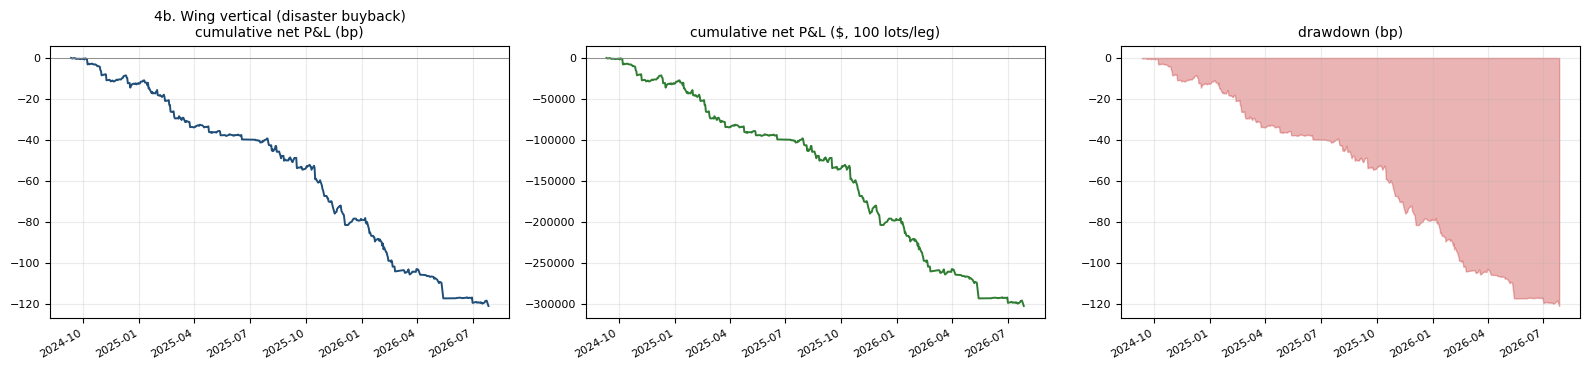


TRADE LOG (first rows)
   key  dir       structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRH26    1 wingvert SFRH26  2024-09-09 2024-09-10 2024-10-08    20  2.123    0.7661      2.5 -1.7339  -4334.63         0.0            2.0        time
SFRU25   -1 wingvert SFRU25  2024-09-30 2024-10-01 2024-10-29    20 -2.058   -0.7794      2.5 -3.2794  -8198.45         0.0            2.0        time
SFRZ25   -1 wingvert SFRZ25  2024-10-02 2024-10-03 2024-10-31    20 -2.144   -0.4144      2.5 -2.9144  -7286.10         0.0            2.0        time
SFRH25   -1 wingvert SFRH25  2024-10-10 2024-10-11 2024-11-08    20 -2.060   -0.3982      2.5 -2.8982  -7245.59         0.0            2.0        time
SFRH25   -1 wingvert SFRH25  2024-11-11 2024-11-12 2024-12-11    20 -2.203    1.5381      2.5 -0.9619  -2404.79         0.0            2.0        time
SFRM25   -1 wingvert SFRM25  2024-11-13 2024-11-14 2024-12-13    20 -2

signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        52           1.608      -128.392  -4.738       0.0
       listed    1        51           6.710      -120.790  -4.669       0.0
same-bar (lag 0) gross inflation: -317.3%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 51          6.71       0.132     0.608       16775.25
           0.5 51        -18.79      -0.368     0.392      -46974.75
           1.0 51        -44.29      -0.868     0.176     -110724.75
           1.5 51        -69.79      -1.368     0.098     -174474.75
           2.5 51       -120.79      -2.368     0.000     -301974.75
           4.0 51       -197.29      -3.868     0.000     -493224.75

4b. Wing vertical (disaster buyback) — median config (not selected)  |  momentum|ma10|w60|z1.0|t20|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 2

In [6]:
out_vert = run_framework(
    "4b. Wing vertical (disaster buyback)", signals=_sig("wing_vertical"),
    book=lab["book"], builder=builder_vertical, base=BASE, grid_spec=GRID,
    params=PARAMS, cls="A",
    note=f"sell {CONFIG['near_offset']*100:.0f}bp / own "
         f"{CONFIG['far_offset']*100:.0f}bp, loss capped at the strike distance")

## 4c — strangle (wing level, no directional tilt)

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 4c. Strangle (wing level) — grid ===
  108 configs | median -368.90bp | IQR [-560.95, -189.38] | 1% net-positive | best +26.37bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1             60               1.5        t20       100     0.530       0.264        26.373       65933.50   0.109   -143.031
 momentum   5            120               1.5        t20        91     0.505      -0.510       -46.454     -116135.50  -0.281   -153.832
 momentum   1            120               1.5        t20        94     0.511      -0.536       -50.385     -125961.50  -0.255   -167.093
 momentum   1             60               2.0        t20        58     0.448      -1.103       -63.953     -159883.75  -0.347   -138.699
 momentum   5             60               1.5        t20        98     0.439      -0.715       -70.039   

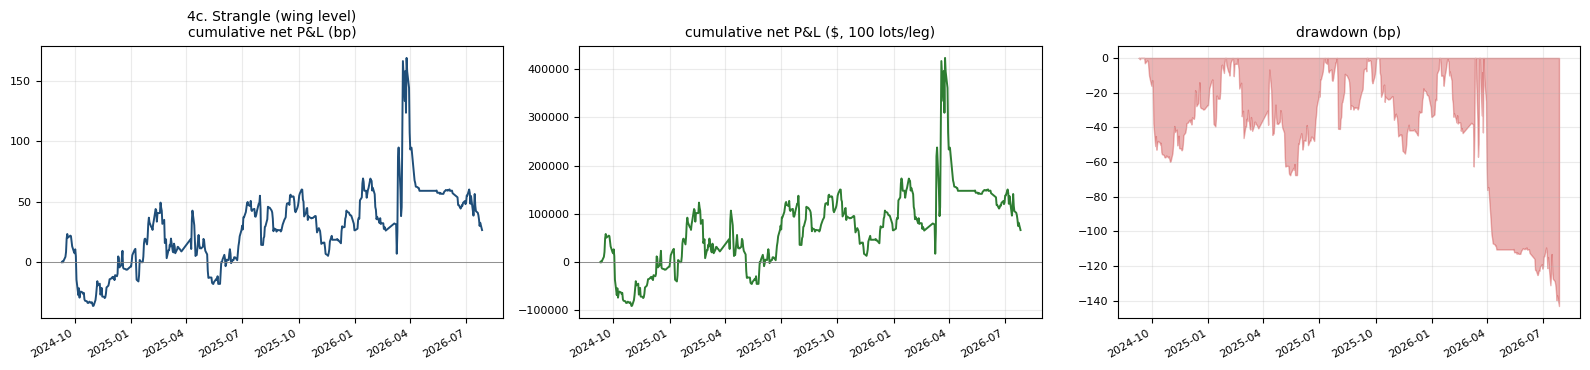


TRADE LOG (first rows)
   key  dir       structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRH26   -1 strangle SFRH26  2024-09-06 2024-09-09 2024-10-07    20 -2.607    0.3998      2.5  -2.1002  -5250.47         0.0            2.0        time
SFRZ25   -1 strangle SFRZ25  2024-09-11 2024-09-12 2024-10-10    20 -1.696    2.4924      2.5  -0.0076    -18.90         0.0            2.0        time
SFRU25   -1 strangle SFRU25  2024-09-16 2024-09-17 2024-10-15    20 -1.674   -3.1077      2.5  -5.6077 -14019.31         0.0            2.0        time
SFRH25   -1 strangle SFRH25  2024-09-18 2024-09-19 2024-10-17    20 -1.655   -7.9695      2.5 -10.4695 -26173.65         0.0            2.0        time
SFRM25   -1 strangle SFRM25  2024-09-18 2024-09-19 2024-10-17    20 -2.259  -10.6174      2.5 -13.1174 -32793.47         0.0            2.0        time
SFRM26   -1 strangle SFRM26  2024-10-15 2024-10-16 2024-11-13   

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0       101     0.515       0.218        21.997       54993.00   0.092   -146.449         18.950
half       107     0.505      -0.331       -35.441      -88601.75  -0.159   -154.939         17.159
  t5       247     0.255      -1.905      -470.597    -1176491.75  -2.541   -483.870          4.992
 t10       162     0.364      -1.444      -233.877     -584692.75  -1.081   -257.015          9.883
 t20       100     0.530       0.264        26.373       65933.50   0.109   -143.031         19.300

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0       105         312.696        50.196   0.205     0.562
       listed    1       100         276.373        26.373   0.109     0.530
same-bar (lag 0) gross inflation: 11.6%

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 100       276.373       2.764      0.64       690933.5
           0.5 100       226.373       2.264      0.61       565933.5
           1.0 100       176.373       1.764      0.59       440933.5
           1.5 100       126.373       1.264      0.58       315933.5
           2.5 100        26.373       0.264      0.53        65933.5
           4.0 100      -123.627      -1.236      0.40      -309066.5

4c. Strangle (wing level) — median config (not selected)  |  momentum|ma5|w60|z1.0|t10|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 cont

In [7]:
out_str = run_framework(
    "4c. Strangle (wing level)", signals=_sig("strangle"), book=lab["book"],
    builder=builder_strangle, base=BASE, grid_spec=GRID, params=PARAMS, cls="A",
    note="both wings, delta-hedged daily")

## FOMC conditioning

Does the wing premium behave differently into a meeting? Entries restricted to
the run-up, everything else unchanged.

eligible bars: 15.4%



=== 4d. Wing harvest (FOMC window) — grid ===
  16 configs | median -143.88bp | IQR [-224.57, -95.53] | 0% net-positive | best -73.84bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   5               1.5         t5        48     0.125      -1.538       -73.843     -184606.50  -3.218    -97.485
 momentum   1               1.5         t5        56     0.161      -1.355       -75.858     -189645.00  -2.684   -125.924
 momentum   5               1.0         t5        68     0.132      -1.211       -82.341     -205851.75  -2.503   -114.715
 momentum   5               1.5        t10        48     0.167      -1.961       -94.111     -235277.75  -2.805   -119.754
 momentum   1               1.5        t10        56     0.196      -1.714       -95.997     -239993.00  -2.092   -152.086
 momentum   5               1.0        t10        68   

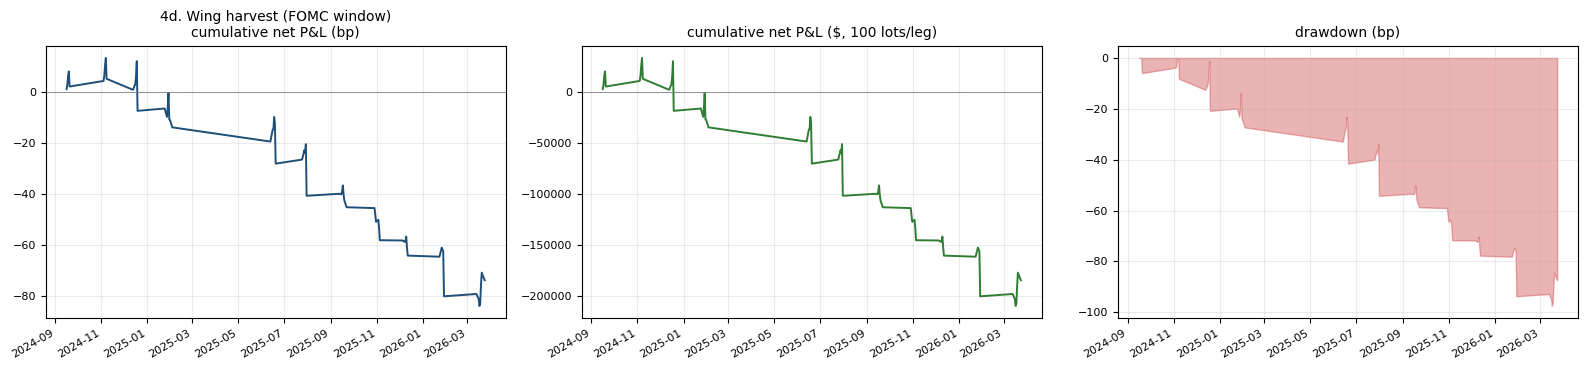


EXIT COMPARISON
exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        48     0.229      -1.701       -81.653     -204132.50  -1.502    -95.917           20.0
half        48     0.229      -1.701       -81.653     -204132.50  -1.502    -95.917           20.0
  t5        48     0.125      -1.538       -73.843     -184606.50  -3.218    -97.485            5.0
 t10        48     0.167      -1.961       -94.111     -235277.75  -2.805   -119.754           10.0
 t20        48     0.229      -1.701       -81.653     -204132.50  -1.502    -95.917           20.0

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        48          66.699       -53.301  -3.152     0.146
       listed    1        48          46.157       -73.843  -3.218     0.125
same-bar (lag 0) gross inflation: 30.8%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 48        46.157       0.962     0.771       115393.5
           0.5 48        22.157       0.462     0.542        55393.5
           1.0 48        -1.843      -0.038     0.438        -4606.5
           1.5 48       -25.843      -0.538     0.208       -64606.5
           2.5 48       -73.843      -1.538     0.125      -184606.5
           4.0 48      -145.843      -3.038     0.021      -364606.5

4d. Wing harvest (FOMC window) — median config (not selected)  |  momentum|ma1|w120|z1.0|t10|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 1 contracts -> position = 100 contr

In [8]:
ev = _sig("hike_wing")
ev["eligible"] = ev["days_to_fomc"].between(-7, -1)
print(f"eligible bars: {ev['eligible'].mean():.1%}")
out_ev = run_framework(
    "4d. Wing harvest (FOMC window)", signals=ev, book=lab["book"],
    builder=builder_naked, base=BASE,
    grid_spec={"direction": list(CONFIG["directions"]), "ma": [1, 5],
               "entry_min_zscore": [1.0, 1.5], "exit_style": ["t5", "t10"]},
    params=["direction", "ma", "entry_min_zscore", "exit_style"], cls="A",
    note="entries limited to 7 business days pre-FOMC", show_trades=0)